In [5]:
!pip install pacmap

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from pacmap import PaCMAP


In [7]:
# Загрузка данных
data = pd.read_csv('depression_treatment_efficiency.csv')

In [8]:
print("Размер данных:", data.shape)
print("Первые 5 строк:")
print(data.head())

Размер данных: (1000, 6)
Первые 5 строк:
   age  symptom_duration  sleep_quality  anxiety_level  life_events  \
0   56                 8              6              8            3   
1   46                 6              4              6            4   
2   32                 6              5              7            4   
3   25                 8              6              9            6   
4   38                 1              4              8            5   

   treatment_success  
0                  0  
1                  1  
2                  1  
3                  0  
4                  0  


In [9]:
X = data.drop('treatment_success', axis=1)
y = data['treatment_success']

In [10]:
# Разделение на обучающую и тестовую выборки (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [11]:
# Нормализация данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
global_model = LogisticRegression(max_iter=1000, random_state=42)
global_model.fit(X_train_scaled, y_train)
y_pred_global = global_model.predict(X_test_scaled)

=== Единая модель ===
Accuracy: 0.793

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       198
           1       0.79      0.54      0.64       102

    accuracy                           0.79       300
   macro avg       0.79      0.73      0.75       300
weighted avg       0.79      0.79      0.78       300

Confusion Matrix:


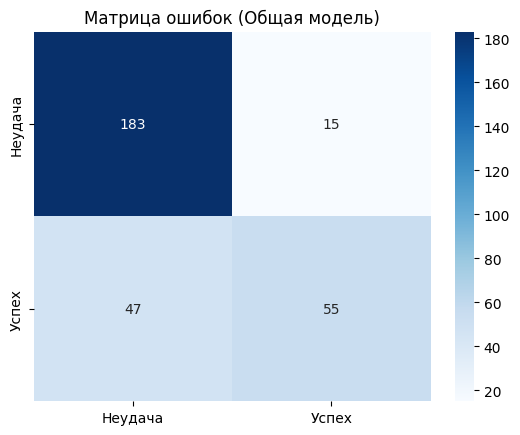

In [13]:
print("=== Единая модель ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_global):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_global))
print("Confusion Matrix:")
cm_global = confusion_matrix(y_test, y_pred_global)
sns.heatmap(cm_global, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Неудача', 'Успех'],
            yticklabels=['Неудача', 'Успех'])
plt.title("Матрица ошибок (Общая модель)")
plt.show()

In [14]:
X_all_scaled = scaler.transform(X)

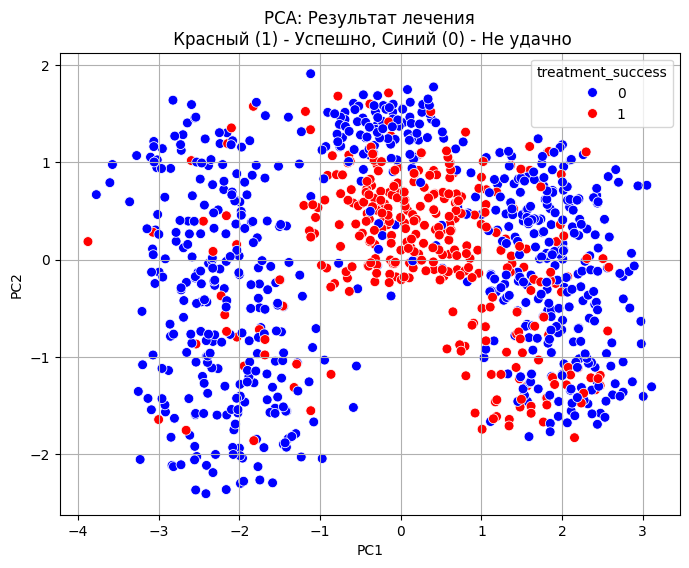

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, s=50, palette={0: 'blue', 1: 'red'})
plt.title('PCA: Результат лечения\n Красный (1) - Успешно, Синий (0) - Не удачно')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid()
plt.show()

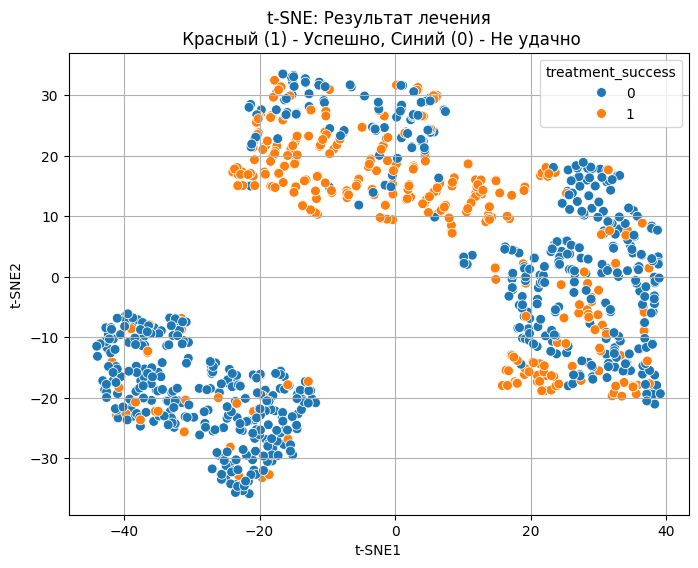

In [16]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_all_scaled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, s=50)
plt.title('t-SNE: Результат лечения\n Красный (1) - Успешно, Синий (0) - Не удачно')
plt.xlabel('t-SNE1')
plt.ylabel('t-SNE2')
plt.grid()
plt.show()

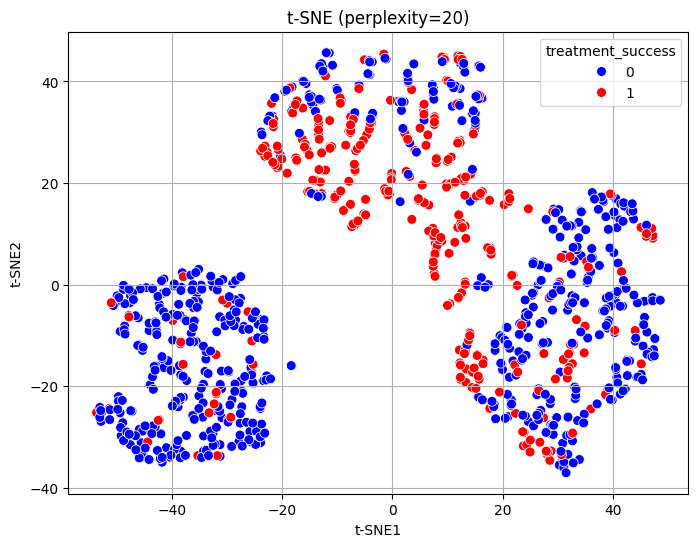

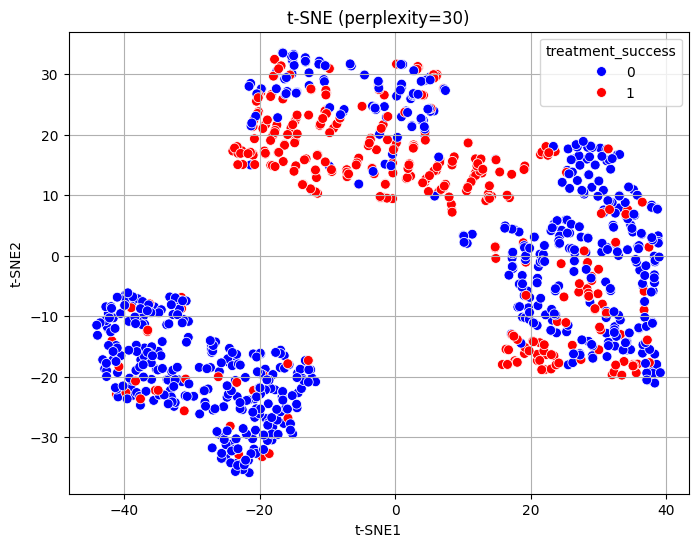

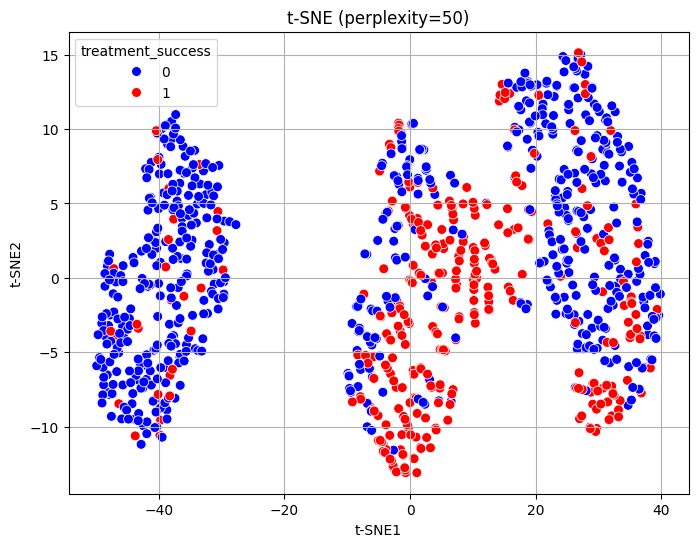

In [17]:
perplexities = [20, 30, 50]
for perp in perplexities:
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X_all_scaled)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, s=50, palette={0: 'blue', 1: 'red'})
    plt.title(f't-SNE (perplexity={perp})')
    plt.xlabel('t-SNE1')
    plt.ylabel('t-SNE2')
    plt.grid()
    plt.show()

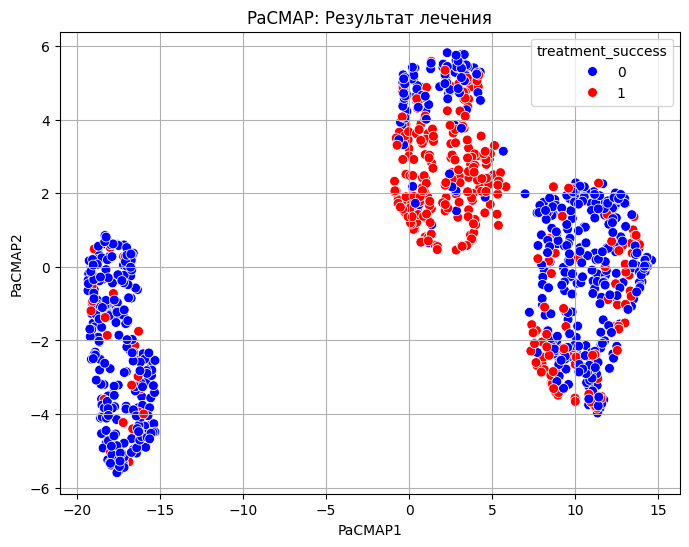

In [18]:
pacmap = PaCMAP(n_components=2, n_neighbors=15, MN_ratio=0.5, FP_ratio=2.0, random_state=42)
X_pacmap = pacmap.fit_transform(X_all_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pacmap[:, 0], y=X_pacmap[:, 1], hue=y, s=50, palette={0: 'blue', 1: 'red'})
plt.title('PaCMAP: Результат лечения')
plt.xlabel('PaCMAP1')
plt.ylabel('PaCMAP2')
plt.grid()
plt.show()

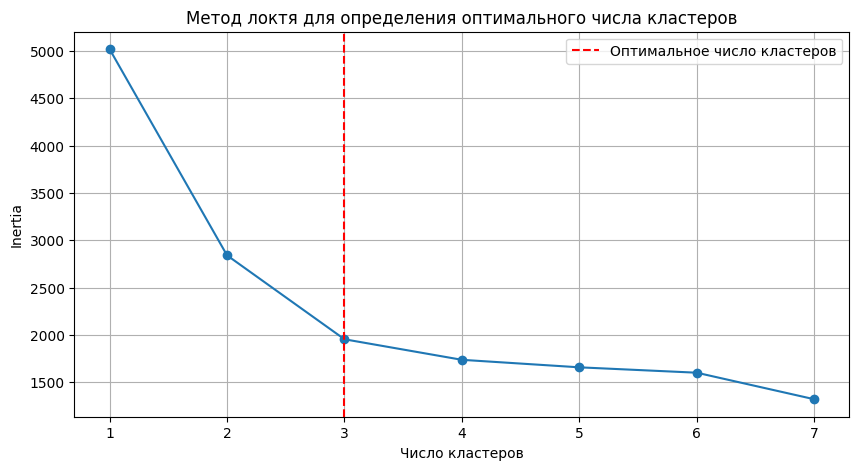

In [19]:
inertia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_all_scaled)  # используем все масштабированные данные
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 8), inertia, marker='o')
plt.xlabel('Число кластеров')
plt.ylabel('Inertia')
plt.title('Метод локтя для определения оптимального числа кластеров')
plt.axvline(x=3, color='r', linestyle='--', label='Оптимальное число кластеров')
plt.legend()
plt.grid()
plt.show()

In [20]:
# Обучаем KMeans с 3 кластерами на обучающей выборке
kmeans = KMeans(n_clusters=3, random_state=42)
clusters_train = kmeans.fit_predict(X_train_scaled)
clusters_test = kmeans.predict(X_test_scaled)

=== Модели для каждого кластера ===

--- Кластер 0 ---
  Количество объектов: 239
  Распределение классов: [ 89 150]
  Accuracy на тесте кластера: 0.844
  Confusion Matrix:


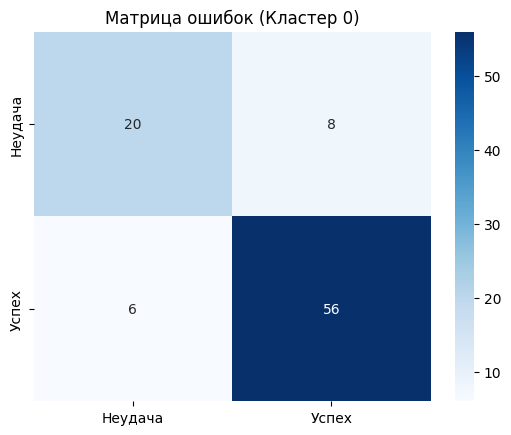


--- Кластер 1 ---
  Количество объектов: 251
  Распределение классов: [180  71]
  Accuracy на тесте кластера: 0.847
  Confusion Matrix:


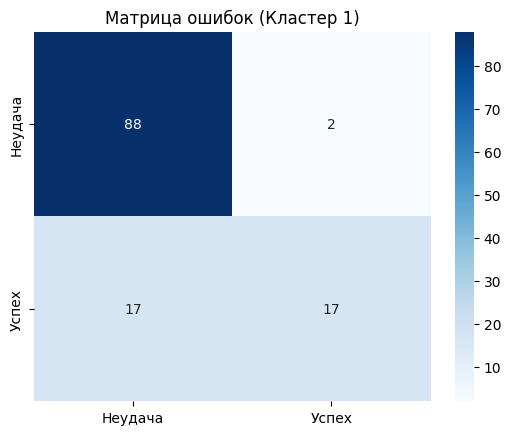


--- Кластер 2 ---
  Количество объектов: 210
  Распределение классов: [188  22]
  Accuracy на тесте кластера: 0.930
  Confusion Matrix:


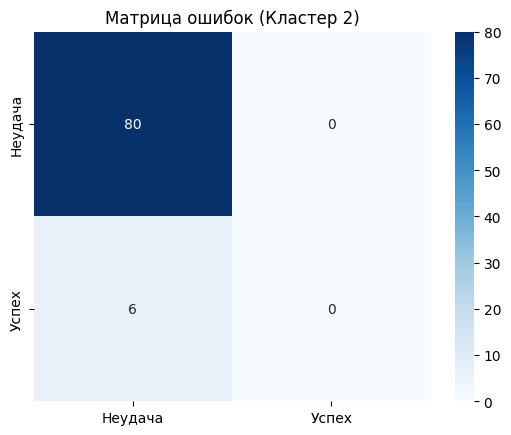

In [21]:
# Обучаем отдельные модели для каждого кластера
cluster_models = {}
print("=== Модели для каждого кластера ===")
for cluster in range(3):
    print(f"\n--- Кластер {cluster} ---")
    X_cluster = X_train_scaled[clusters_train == cluster]
    y_cluster = y_train[clusters_train == cluster]

    # Проверка, есть ли в кластере оба класса
    print(f"  Количество объектов: {len(X_cluster)}")
    print(f"  Распределение классов: {np.bincount(y_cluster)}")

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_cluster, y_cluster)
    cluster_models[cluster] = model

    # Оценка на тестовых данных этого кластера
    X_test_cluster = X_test_scaled[clusters_test == cluster]
    y_test_cluster = y_test[clusters_test == cluster]

    if len(X_test_cluster) > 0:
        y_pred_cluster = model.predict(X_test_cluster)
        acc = accuracy_score(y_test_cluster, y_pred_cluster)
        print(f"  Accuracy на тесте кластера: {acc:.3f}")
        print("  Confusion Matrix:")
        cm = confusion_matrix(y_test_cluster, y_pred_cluster)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Неудача', 'Успех'],
                    yticklabels=['Неудача', 'Успех'])
        plt.title(f"Матрица ошибок (Кластер {cluster})")
        plt.show()
    else:
        print("  Нет тестовых объектов в этом кластере")


=== Итоговая оценка кластерного подхода ===
Accuracy: 0.870

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       198
           1       0.88      0.72      0.79       102

    accuracy                           0.87       300
   macro avg       0.87      0.83      0.85       300
weighted avg       0.87      0.87      0.87       300

Confusion Matrix:


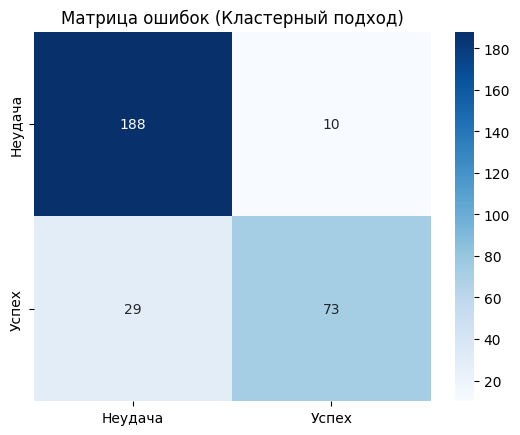

In [22]:
# Сводная оценка кластерного подхода
y_pred_cluster_total = np.zeros(len(y_test))
for cluster in cluster_models:
    y_pred_cluster_total[clusters_test == cluster] = cluster_models[cluster].predict(
        X_test_scaled[clusters_test == cluster]
    )

total_acc = accuracy_score(y_test, y_pred_cluster_total)
print("\n=== Итоговая оценка кластерного подхода ===")
print(f"Accuracy: {total_acc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cluster_total))
print("Confusion Matrix:")
cm_total = confusion_matrix(y_test, y_pred_cluster_total)
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Неудача', 'Успех'],
            yticklabels=['Неудача', 'Успех'])
plt.title("Матрица ошибок (Кластерный подход)")
plt.show()

In [23]:
new_patient = pd.DataFrame([{
    'age': 35,
    'symptom_duration': 3,
    'sleep_quality': 3,
    'anxiety_level': 4,
    'life_events': 3
}])

In [24]:
# Нормализация
new_patient_scaled = scaler.transform(new_patient)

In [25]:
# Определяем кластер
cluster = kmeans.predict(new_patient_scaled)[0]
print(f"\n=== Новый пациент ===")
print(f"Пациент относится к кластеру: {cluster}")


=== Новый пациент ===
Пациент относится к кластеру: 0


In [26]:
# Предсказание
effectiveness = cluster_models[cluster].predict(new_patient_scaled)[0]
effectiveness_proba = cluster_models[cluster].predict_proba(new_patient_scaled)[0][1]
print(f"Эффективность КПТ: {'Успех' if effectiveness == 1 else 'Неудача'}")
print(f"Вероятность успеха: {effectiveness_proba:.3f}")

Эффективность КПТ: Успех
Вероятность успеха: 0.992


In [27]:
# Дополнительно: сравнение с предсказанием единой модели
global_pred = global_model.predict(new_patient_scaled)[0]
global_proba = global_model.predict_proba(new_patient_scaled)[0][1]
print(f"\nЕдиная модель предсказывает: {'Успех' if global_pred == 1 else 'Неудача'}, вероятность {global_proba:.3f}")


Единая модель предсказывает: Успех, вероятность 0.724


In [28]:
print("=== Аудит данных ===")
print(f"Размер датасета: {data.shape[0]} строк, {data.shape[1]} столбцов")
print("\nПропуски по столбцам:")
print(data.isna().sum())

print("\nРаспределение целевого класса:")
class_share = data['treatment_success'].value_counts(normalize=True).sort_index()
print(pd.DataFrame({
    'count': data['treatment_success'].value_counts().sort_index(),
    'share': class_share.round(3)
}))

print("\nОписательная статистика по признакам:")
display(data.describe().T)


=== Аудит данных ===
Размер датасета: 1000 строк, 6 столбцов

Пропуски по столбцам:
age                  0
symptom_duration     0
sleep_quality        0
anxiety_level        0
life_events          0
treatment_success    0
dtype: int64

Распределение целевого класса:
                   count  share
treatment_success              
0                    655  0.655
1                    345  0.345

Описательная статистика по признакам:


,count,mean,std,min,25%,50%,75%,max
age,1000.0,47.347,14.289534,18.0,38.0,48.0,58.0,79.0
symptom_duration,1000.0,9.937,9.970579,1.0,3.0,5.0,16.0,35.0
sleep_quality,1000.0,3.959,1.692981,1.0,3.0,4.0,5.0,7.0
anxiety_level,1000.0,6.015,1.688083,3.0,5.0,6.0,7.0,9.0
life_events,1000.0,2.651,1.744776,0.0,1.0,3.0,4.0,6.0
treatment_success,1000.0,0.345,0.475606,0.0,0.0,0.0,1.0,1.0


In [29]:
# Кросс-валидация и подбор гиперпараметров на обучающей выборке
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Вероятности для кластерного подхода нужны для ROC-AUC и общего сравнения
cluster_proba_total = np.zeros(len(y_test), dtype=float)
for cluster in cluster_models:
    idx = clusters_test == cluster
    if idx.sum() > 0:
        cluster_proba_total[idx] = cluster_models[cluster].predict_proba(X_test_scaled[idx])[:, 1]

# Базовая логистическая регрессия в пайплайне без утечек по scaler
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, random_state=42))
])

lr_param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__class_weight': [None, 'balanced'],
    'clf__solver': ['liblinear', 'lbfgs']
}

lr_grid = GridSearchCV(
    estimator=lr_pipe,
    param_grid=lr_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)
lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_
lr_pred = best_lr.predict(X_test)
lr_proba = best_lr.predict_proba(X_test)[:, 1]

# Дополнительный baseline для табличных данных
rf_pipe = Pipeline([
    ('clf', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 4, 6, 10],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)
rf_proba = best_rf.predict_proba(X_test)[:, 1]

# Сравнение моделей
summary_rows = []

def add_metrics(name, y_true, y_pred, y_prob):
    summary_rows.append({
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob)
    })

add_metrics('Baseline LogisticRegression', y_test, y_pred_global, global_model.predict_proba(X_test_scaled)[:, 1])
add_metrics('Tuned LogisticRegression (Pipeline)', y_test, lr_pred, lr_proba)
add_metrics('RandomForest (Tuned)', y_test, rf_pred, rf_proba)
add_metrics('Cluster-based LogisticRegression', y_test, y_pred_cluster_total, cluster_proba_total)

summary_df = pd.DataFrame(summary_rows).sort_values(by=['f1', 'roc_auc', 'accuracy'], ascending=False)
display(summary_df.style.format({
    'accuracy': '{:.3f}',
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1': '{:.3f}',
    'roc_auc': '{:.3f}',
}))

print("\nЛучшие параметры LogisticRegression:")
print(lr_grid.best_params_)
print(f"CV F1 (mean ± std): {lr_grid.best_score_:.3f}")

print("\nЛучшие параметры RandomForest:")
print(rf_grid.best_params_)
print(f"CV F1 (mean ± std): {rf_grid.best_score_:.3f}")


,model,accuracy,precision,recall,f1,roc_auc
2,RandomForest (Tuned),0.903,0.910,0.794,0.848,0.876
3,Cluster-based LogisticRegression,0.870,0.880,0.716,0.789,0.881
1,Tuned LogisticRegression (Pipeline),0.743,0.585,0.843,0.691,0.843
0,Baseline LogisticRegression,0.793,0.786,0.539,0.640,0.843



Лучшие параметры LogisticRegression:
{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__solver': 'liblinear'}
CV F1 (mean ± std): 0.657

Лучшие параметры RandomForest:
{'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
CV F1 (mean ± std): 0.850


In [30]:
# Более полная оценка качества для кластерного подхода
cluster_acc = accuracy_score(y_test, y_pred_cluster_total)
cluster_prec = precision_score(y_test, y_pred_cluster_total, zero_division=0)
cluster_rec = recall_score(y_test, y_pred_cluster_total, zero_division=0)
cluster_f1 = f1_score(y_test, y_pred_cluster_total, zero_division=0)
cluster_auc = roc_auc_score(y_test, cluster_proba_total)

print("=== Кластерный подход: расширенная оценка ===")
print(f"Accuracy:  {cluster_acc:.3f}")
print(f"Precision: {cluster_prec:.3f}")
print(f"Recall:    {cluster_rec:.3f}")
print(f"F1:        {cluster_f1:.3f}")
print(f"ROC-AUC:   {cluster_auc:.3f}")


=== Кластерный подход: расширенная оценка ===
Accuracy:  0.870
Precision: 0.880
Recall:    0.716
F1:        0.789
ROC-AUC:   0.881


,feature,coefficient,abs_coefficient
1,symptom_duration,-1.186263,1.186263
4,life_events,-0.454060,0.454060
3,anxiety_level,-0.423875,0.423875
0,age,-0.264375,0.264375
2,sleep_quality,0.121268,0.121268


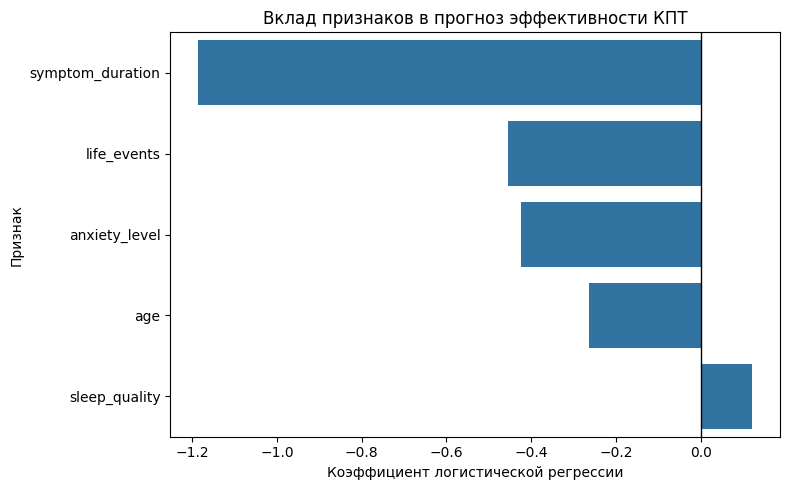


Топ положительных факторов:
      feature  coefficient
sleep_quality     0.121268
          age    -0.264375
anxiety_level    -0.423875

Топ отрицательных факторов:
         feature  coefficient
symptom_duration    -1.186263
     life_events    -0.454060
   anxiety_level    -0.423875


In [31]:
# Интерпретация лучших коэффициентов логистической регрессии
feature_names = X.columns.tolist()
coef = best_lr.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef,
    'abs_coefficient': np.abs(coef)
}).sort_values('abs_coefficient', ascending=False)

display(coef_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x='coefficient', y='feature')
plt.axvline(0, color='black', linewidth=1)
plt.title('Вклад признаков в прогноз эффективности КПТ')
plt.xlabel('Коэффициент логистической регрессии')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

print("\nТоп положительных факторов:")
print(coef_df.sort_values('coefficient', ascending=False)[['feature', 'coefficient']].head(3).to_string(index=False))

print("\nТоп отрицательных факторов:")
print(coef_df.sort_values('coefficient', ascending=True)[['feature', 'coefficient']].head(3).to_string(index=False))
